# 用训练得到的模型预测-单张图片

同济子豪兄 2023-2-15 6-11 6-25

## 进入MMSegmentation主目录

In [1]:
# import os
# os.chdir('mmsegmentation')

import os
# 假设 mmsegmentation 的绝对路径是 /project/mmsegmentation
mmsegmentation_path = "E:/bishe_demo/mmsegmentation-main"
# 切换到 mmsegmentation 文件夹
os.chdir(mmsegmentation_path)
# 验证当前工作目录
print("当前工作目录:", os.getcwd())  # 输出: /project/mmsegmentation

当前工作目录: E:\bishe_demo\mmsegmentation-main


In [2]:
os.getcwd()

'E:\\bishe_demo\\mmsegmentation-main'

## 导入工具包

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mmseg.apis import init_model, inference_model, show_result_pyplot
import mmcv
import cv2

## 载入模型：KNet

In [4]:
# # 模型 config 配置文件
# config_file = 'Zihao-Configs/ZihaoDataset_KNet_20230818.py'
# 
# # 模型 checkpoint 权重文件
# checkpoint_file = 'checkpoint/Zihao_KNet.pth'
# 
# # device = 'cpu'
# device = 'cuda:0'
# 
# model = init_model(config_file, checkpoint_file, device=device)

# 模型 config 配置文件
config_file = 'Zihao-Configs/ZihaoDataset_PSPNet_20230818.py'

# 模型 checkpoint 权重文件
checkpoint_file = 'work_dirs/ZihaoDataset-PSPNet/best_mIoU_iter_1000.pth'

# device = 'cpu'
device = 'cuda:0'

model = init_model(config_file, checkpoint_file, device=device)

Loads checkpoint by local backend from path: work_dirs/ZihaoDataset-PSPNet/best_mIoU_iter_1000.pth


E:\bishe_demo\mmsegmentation-main\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


## 载入模型：Fast-SCNN

In [9]:
# # 模型 config 配置文件
# config_file = 'Zihao-Configs/ZihaoDataset_FastSCNN_20230818.py'

# # 模型 checkpoint 权重文件
# checkpoint_file = 'checkpoint/Zihao_FastSCNN.pth'

# # device = 'cpu'
# device = 'cuda:0'

# model = init_model(config_file, checkpoint_file, device=device)

## 载入测试集图像，或新图像

In [38]:
# img_path = 'Watermelon87_Semantic_Seg_Mask/img_dir/val/01bd15599c606aa801201794e1fa30.jpg'

img_path = './data/cityscapes/leftImg8bit/val/frankfurt/frankfurt_000000_001016_leftImg8bit.png'


# img_path = 'Watermelon87_Semantic_Seg_Mask/img_dir/val/la_wm_img01.jpg'

# img_path = 'data/watermelon_test1.jpg'

In [39]:
img_bgr = cv2.imread(img_path)

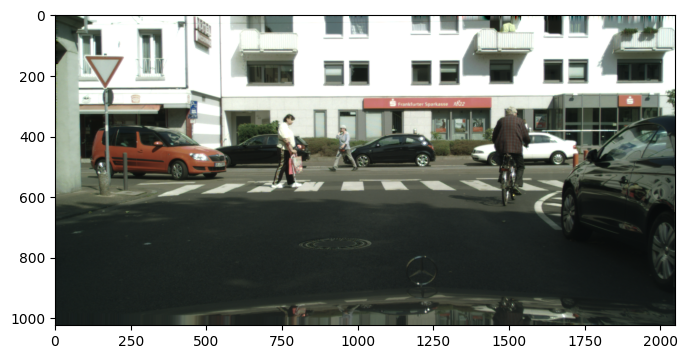

In [40]:
plt.figure(figsize=(8, 8))
plt.imshow(img_bgr[:,:,::-1])
plt.show()

## 语义分割预测

In [41]:
result = inference_model(model, img_bgr)

In [42]:
result.keys()

['seg_logits', 'pred_sem_seg']

In [84]:
pred_mask = result.pred_sem_seg.data[0].cpu().numpy()

In [85]:
pred_mask.shape

(1024, 2048)

In [86]:
np.unique(pred_mask)

array([ 0,  1,  2,  4,  5,  7,  8, 10, 11, 13, 18], dtype=int64)

## 语义分割预测结果-定性

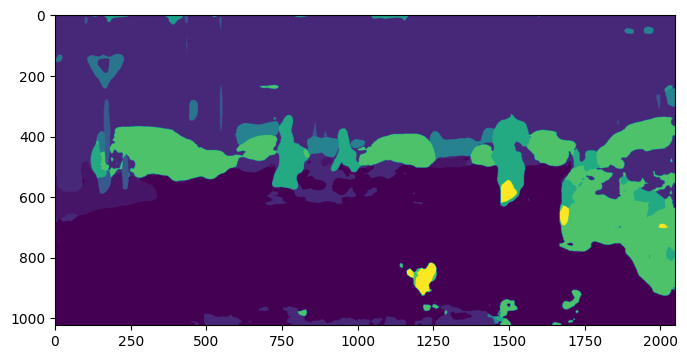

In [46]:
plt.figure(figsize=(8, 8))
plt.imshow(pred_mask)
plt.savefig('outputs/K1-0.jpg')
plt.show()

## 语义分割预测结果-定量

In [47]:
result.seg_logits.data.shape

torch.Size([19, 1024, 2048])

## 可视化语义分割预测结果-方法一

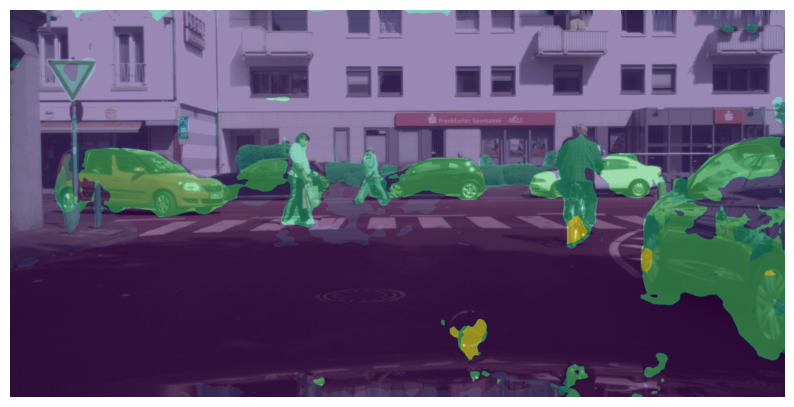

In [48]:
# 显示语义分割结果
plt.figure(figsize=(10, 8))
plt.imshow(img_bgr[:,:,::-1])
plt.imshow(pred_mask, alpha=0.55) # alpha 高亮区域透明度，越小越接近原图
plt.axis('off')
plt.savefig('outputs/K1-1.jpg')
plt.show()

## 可视化语义分割预测结果-方法二（和原图并排显示）

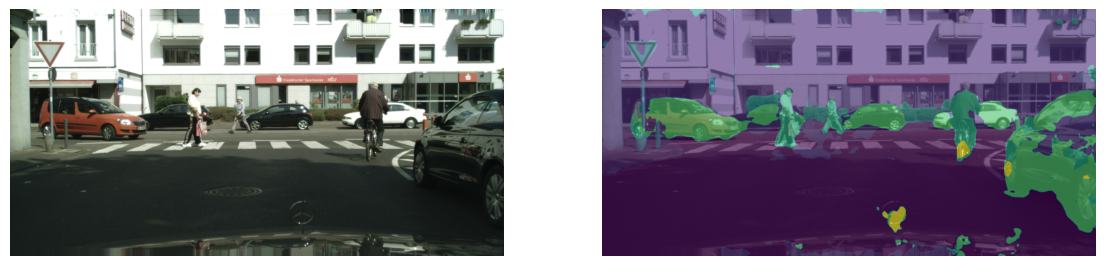

In [49]:
plt.figure(figsize=(14, 8))

plt.subplot(1,2,1)
plt.imshow(img_bgr[:,:,::-1])
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_bgr[:,:,::-1])
plt.imshow(pred_mask, alpha=0.6) # alpha 高亮区域透明度，越小越接近原图
plt.axis('off')
plt.savefig('outputs/K1-2.jpg')
plt.show()

## 可视化语义分割预测结果-方法三（按配色方案叠加在原图上显示）

In [60]:
# # 各类别的配色方案（BGR）
# palette = [
#     ['background', [127,127,127]],
#     ['red', [0,0,200]],
#     ['green', [0,200,0]],
#     ['white', [144,238,144]],
#     ['seed-black', [30,30,30]],
#     ['seed-white', [8,189,251]]
# ]
# 
# palette_dict = {}
# for idx, each in enumerate(palette):
#     palette_dict[idx] = each[1]

# 自定义 Cityscapes 19 个类别的配色方案（BGR 格式）
palette = [
    ['road', [100, 100, 100]],  # 道路
    ['sidewalk', [200, 50, 200]],  # 人行道
    ['building', [50, 50, 50]],  # 建筑
    ['wall', [150, 150, 200]],  # 墙
    ['fence', [200, 150, 150]],  # 栅栏
    ['pole', [150, 150, 150]],  # 杆子
    ['traffic light', [255, 200, 0]],  # 交通灯
    ['traffic sign', [255, 255, 0]],  # 交通标志
    ['vegetation', [0, 200, 0]],  # 植被
    ['terrain', [200, 255, 200]],  # 地形
    ['sky', [0, 150, 255]],  # 天空
    ['person', [255, 0, 0]],  # 人
    ['rider', [255, 100, 0]],  # 骑行者
    ['car', [0, 0, 255]],  # 汽车
    ['truck', [0, 0, 150]],  # 卡车
    ['bus', [0, 100, 150]],  # 公交车
    ['train', [0, 150, 150]],  # 火车
    ['motorcycle', [0, 0, 200]],  # 摩托车
    ['bicycle', [200, 0, 100]]  # 自行车
]

# 将 palette 转换为字典格式
palette_dict = {}
for idx, each in enumerate(palette):
    palette_dict[idx] = each[1]

# # 打印结果
# print(palette_dict)

In [61]:
palette_dict

{0: [100, 100, 100],
 1: [200, 50, 200],
 2: [50, 50, 50],
 3: [150, 150, 200],
 4: [200, 150, 150],
 5: [150, 150, 150],
 6: [255, 200, 0],
 7: [255, 255, 0],
 8: [0, 200, 0],
 9: [200, 255, 200],
 10: [0, 150, 255],
 11: [255, 0, 0],
 12: [255, 100, 0],
 13: [0, 0, 255],
 14: [0, 0, 150],
 15: [0, 100, 150],
 16: [0, 150, 150],
 17: [0, 0, 200],
 18: [200, 0, 100]}

In [62]:
opacity = 0.3 # 透明度，越大越接近原图

In [63]:
# 将预测的整数ID，映射为对应类别的颜色
pred_mask_bgr = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3))
for idx in palette_dict.keys():
    pred_mask_bgr[np.where(pred_mask==idx)] = palette_dict[idx]
pred_mask_bgr = pred_mask_bgr.astype('uint8')

# 将语义分割预测图和原图叠加显示
pred_viz = cv2.addWeighted(img_bgr, opacity, pred_mask_bgr, 1-opacity, 0)

cv2.imwrite('outputs/K1-3.jpg', pred_viz)

True

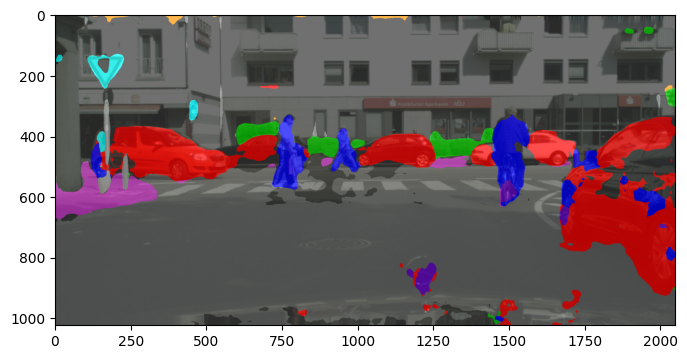

In [64]:
plt.figure(figsize=(8, 8))
plt.imshow(pred_viz[:,:,::-1])
plt.show()

## 可视化语义分割预测结果-方法三

按照`mmseg/datasets/ZihaoDataset.py`里定义的类别颜色可视化

In [65]:
from mmseg.apis import show_result_pyplot

In [66]:
img_viz = show_result_pyplot(model, img_path, result, opacity=0.8, title='MMSeg', out_file='outputs/K1-4.jpg')

#会出现出现警告不用管

E:\anaconda3\envs\openmmlab\lib\site-packages\mmengine\visualization\visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


opacity控制透明度，越小，越接近原图。

In [67]:
img_viz.shape

(1024, 2048, 3)

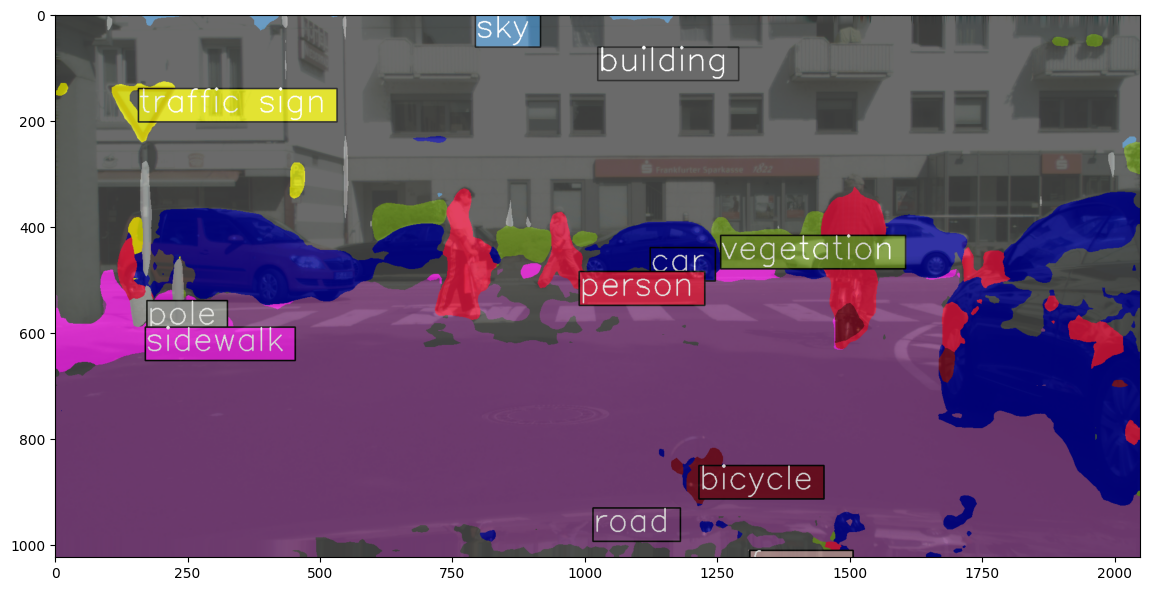

In [68]:
plt.figure(figsize=(14, 8))
plt.imshow(img_viz)
plt.show()

## 可视化语义分割预测结果-方法四（加图例）

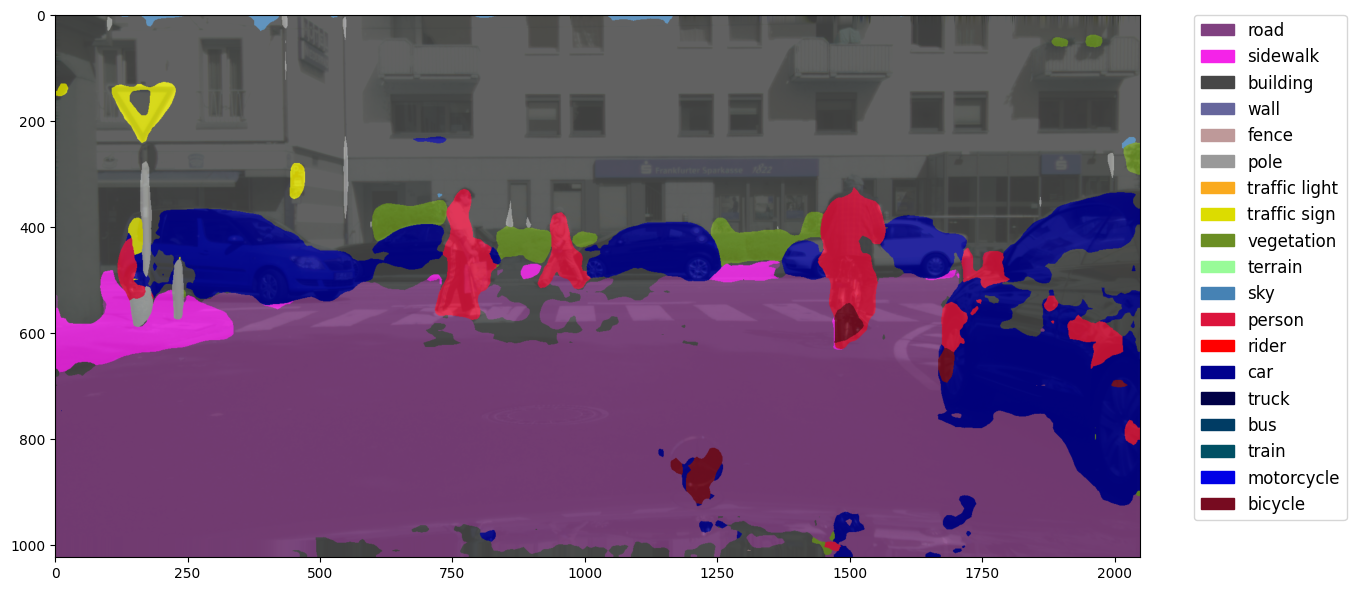

In [71]:
# from mmseg.datasets import ZihaoDataset #这个是西瓜的
# import numpy as np
# import mmcv 
# from PIL import Image
# 
# # 获取类别名和调色板
# classes = ZihaoDataset.METAINFO['classes']
# palette = ZihaoDataset.METAINFO['palette']
# opacity = 0.15 # 透明度，越大越接近原图
# 
# # 将分割图按调色板染色
# # seg_map = result[0].astype('uint8')
# seg_map = pred_mask.astype('uint8')
# seg_img = Image.fromarray(seg_map).convert('P')
# seg_img.putpalette(np.array(palette, dtype=np.uint8))
# 
# from matplotlib import pyplot as plt
# import matplotlib.patches as mpatches
# plt.figure(figsize=(14, 8))
# img_plot = ((np.array(seg_img.convert('RGB')))*(1-opacity) + mmcv.imread(img_path)*opacity) / 255
# im = plt.imshow(img_plot)
# 
# # 为每一种颜色创建一个图例
# patches = [mpatches.Patch(color=np.array(palette[i])/255., label=classes[i]) for i in range(len(classes))]
# plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize='large')
# 
# plt.savefig('outputs/K1-6.jpg')
# plt.show()


from mmseg.datasets import CityscapesDataset
import numpy as np
import mmcv 
from PIL import Image

# 获取类别名和调色板
classes = CityscapesDataset.METAINFO['classes']
palette = CityscapesDataset.METAINFO['palette']
opacity = 0.15 # 透明度，越大越接近原图

# 将分割图按调色板染色
# seg_map = result[0].astype('uint8')
seg_map = pred_mask.astype('uint8')
seg_img = Image.fromarray(seg_map).convert('P')
seg_img.putpalette(np.array(palette, dtype=np.uint8))

from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
plt.figure(figsize=(14, 8))
img_plot = ((np.array(seg_img.convert('RGB')))*(1-opacity) + mmcv.imread(img_path)*opacity) / 255
im = plt.imshow(img_plot)

# 为每一种颜色创建一个图例
patches = [mpatches.Patch(color=np.array(palette[i])/255., label=classes[i]) for i in range(len(classes))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize='large')

plt.savefig('outputs/K1-6.jpg')
plt.show()

## 获取测试集标注

In [72]:
label_path = 'data/cityscapes/gtFine/val/frankfurt/frankfurt_000000_001016_gtFine_color.png'

# label_path = 'Watermelon87_Semantic_Seg_Mask/ann_dir/val/la_wm_img01.png'

In [73]:
label = cv2.imread(label_path)

In [74]:
label.shape

(1024, 2048, 3)

三个通道全部一样，只取一个通道作为标注即可。

In [75]:
label_mask = label[:,:,0]

In [76]:
label_mask.shape

(1024, 2048)

In [77]:
np.unique(label_mask)

array([  0,  32,  35,  60,  70, 128, 142, 153, 232], dtype=uint8)

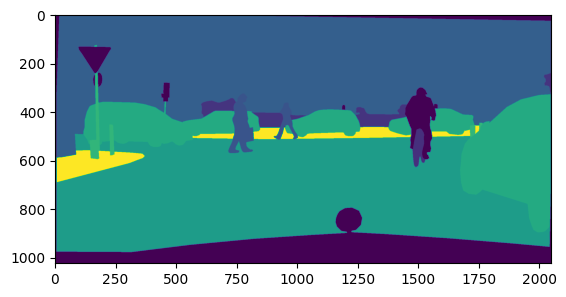

In [78]:
plt.imshow(label_mask)
plt.show()

## 对比测试集标注和语义分割预测结果

In [79]:
# 测试集标注
label_mask.shape

(1024, 2048)

In [80]:
# 语义分割预测结果
pred_mask.shape

(1024, 2048)

In [81]:
classes

('road',
 'sidewalk',
 'building',
 'wall',
 'fence',
 'pole',
 'traffic light',
 'traffic sign',
 'vegetation',
 'terrain',
 'sky',
 'person',
 'rider',
 'car',
 'truck',
 'bus',
 'train',
 'motorcycle',
 'bicycle')

In [87]:
# 真实为 西瓜红瓤，预测为 西瓜红壤
TP = (label_mask == 1) & (pred_mask==1)

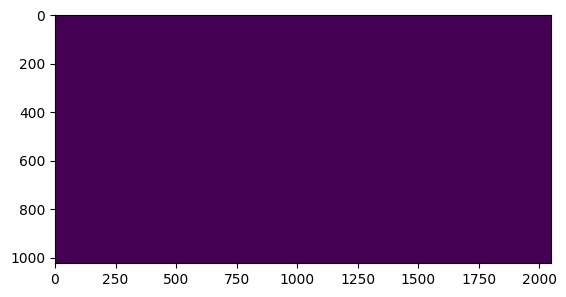

In [88]:
plt.imshow(TP)
plt.show()

## 绘制混淆矩阵

In [89]:
from sklearn.metrics import confusion_matrix

In [90]:
confusion_matrix_model = confusion_matrix(label_mask.flatten(), pred_mask.flatten())

In [91]:
confusion_matrix_model

array([[157658,    692,  58483,      7,     68,   7988,    974,   2359,
         17362,   8307,   4990,      0,      0,      0,      0,      0,
             0,      0,      0],
       [     0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0],
       [     0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0],
       [     0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0],
       [     0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0],
       [     0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,    

In [92]:
import itertools
def cnf_matrix_plotter(cm, classes, cmap=plt.cm.Blues):
    """
    传入混淆矩阵和标签名称列表，绘制混淆矩阵
    """
    plt.figure(figsize=(10, 10))
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    # plt.colorbar() # 色条
    tick_marks = np.arange(len(classes))
    
    plt.title('Confusion Matrix', fontsize=30)
    plt.xlabel('Pred', fontsize=25, c='r')
    plt.ylabel('True', fontsize=25, c='r')
    plt.tick_params(labelsize=16) # 设置类别文字大小
    plt.xticks(tick_marks, classes, rotation=90) # 横轴文字旋转
    plt.yticks(tick_marks, classes)
    
    # 写数字
    threshold = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > threshold else "black",
                 fontsize=12)

    plt.tight_layout()

    plt.savefig('outputs/K1-混淆矩阵.pdf', dpi=300) # 保存图像
    plt.show()

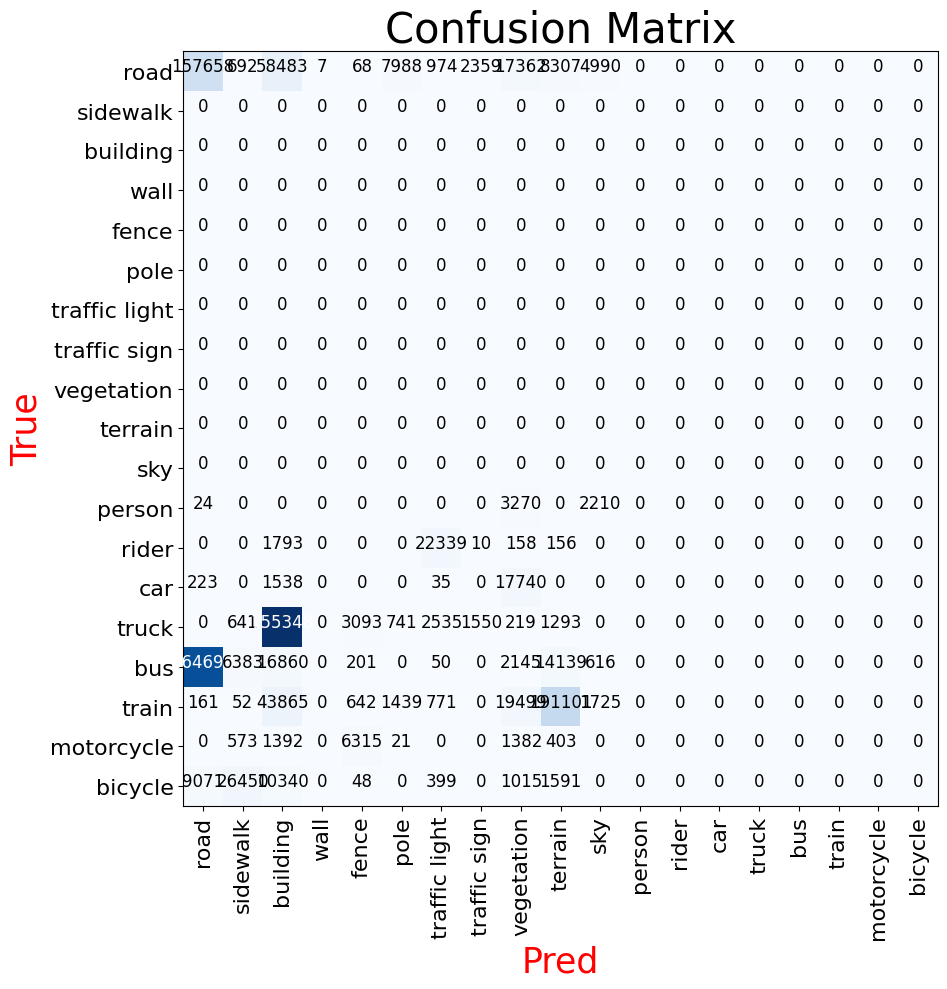

In [93]:
cnf_matrix_plotter(confusion_matrix_model, classes, cmap='Blues')
#主对角线 越有值，说明越好